#### Manufacturing Quality Control – Statistical Distribution Analysis

This dataset was designed for a statistical process monitoring project in an industrial manufacturing environment, where each production batch is tracked across 12 sensor and inspection variables including tensile strength, machine temperature, cycle times, defect counts, and material purity.

The goal is to demonstrate and validate that real-world manufacturing variables naturally follow different statistical distributions — Normal, Exponential, Poisson, Binomial, and Uniform — and to apply formal goodness-of-fit and normality tests (Shapiro-Wilk, KS, Anderson-Darling, Chi-Square) on each column to confirm distributional assumptions before applying statistical process control (SPC) or predictive quality models. This project serves as a foundation for Six Sigma analysis, control chart design, and reliability engineering, where knowing the correct underlying distribution of each variable is critical for setting tolerances, predicting failures, and maintaining product quality standards.

In [1]:
#✅ What This Code Does Step by Step
# 1.Load dataset and detect numeric columns.
# 2.Plot histograms with skewness values.
# 3.Shapiro-Wilk test for normality.
# 4.Fit distributions: Bernoulli, Binomial, Poisson (Chi-square), Normal, Uniform, Exponential, Student’s t (KS-test).
# 5.Scaling fix applied for Chi-square to avoid ValueError.
# 6.Plot histograms + Q-Q plots.
# 7.Final summary table showing skewness, normality p-value, and best-fit distribution.

In [2]:
# ===============================================
# Manufacturing Quality Control - Full Distribution Analysis
# ===============================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats  # correct import for probplot
from scipy.stats import shapiro, norm, expon, uniform, t, poisson, binom, bernoulli, kstest, chisquare
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 2️⃣ Load the dataset
df = pd.read_csv("manufacturing_quality_control.csv")
numeric_cols = df.select_dtypes(include=np.number).columns
print("Dataset Columns:", numeric_cols)
display(df.head())

Dataset Columns: Index(['batch_id', 'tensile_strength_MPa', 'machine_temperature_C',
       'cycle_time_sec', 'inter_failure_hours', 'defects_per_batch',
       'surface_defects_per_m2', 'pass_fail', 'items_passed_per_lot50',
       'sensor_voltage_V', 'raw_material_purity_pct', 'load_stress_MPa',
       'humidity_pct'],
      dtype='str')


,batch_id,tensile_strength_MPa,machine_temperature_C,cycle_time_sec,inter_failure_hours,defects_per_batch,surface_defects_per_m2,pass_fail,items_passed_per_lot50,sensor_voltage_V,raw_material_purity_pct,load_stress_MPa,humidity_pct
0,1,528.94,180.27,29.86,117.12,2,1,1,47,3.3632,99.051,293.51,40.76
1,2,517.51,183.99,4.02,9.28,4,1,1,49,3.7108,98.041,338.07,38.54
2,3,531.66,179.45,161.65,84.07,2,0,1,45,3.4365,98.826,288.55,46.17
3,4,547.41,182.84,32.84,24.20,2,1,1,48,3.6258,97.720,322.36,46.41
4,5,515.79,171.74,42.86,102.39,3,3,1,48,3.2886,97.139,277.01,49.94


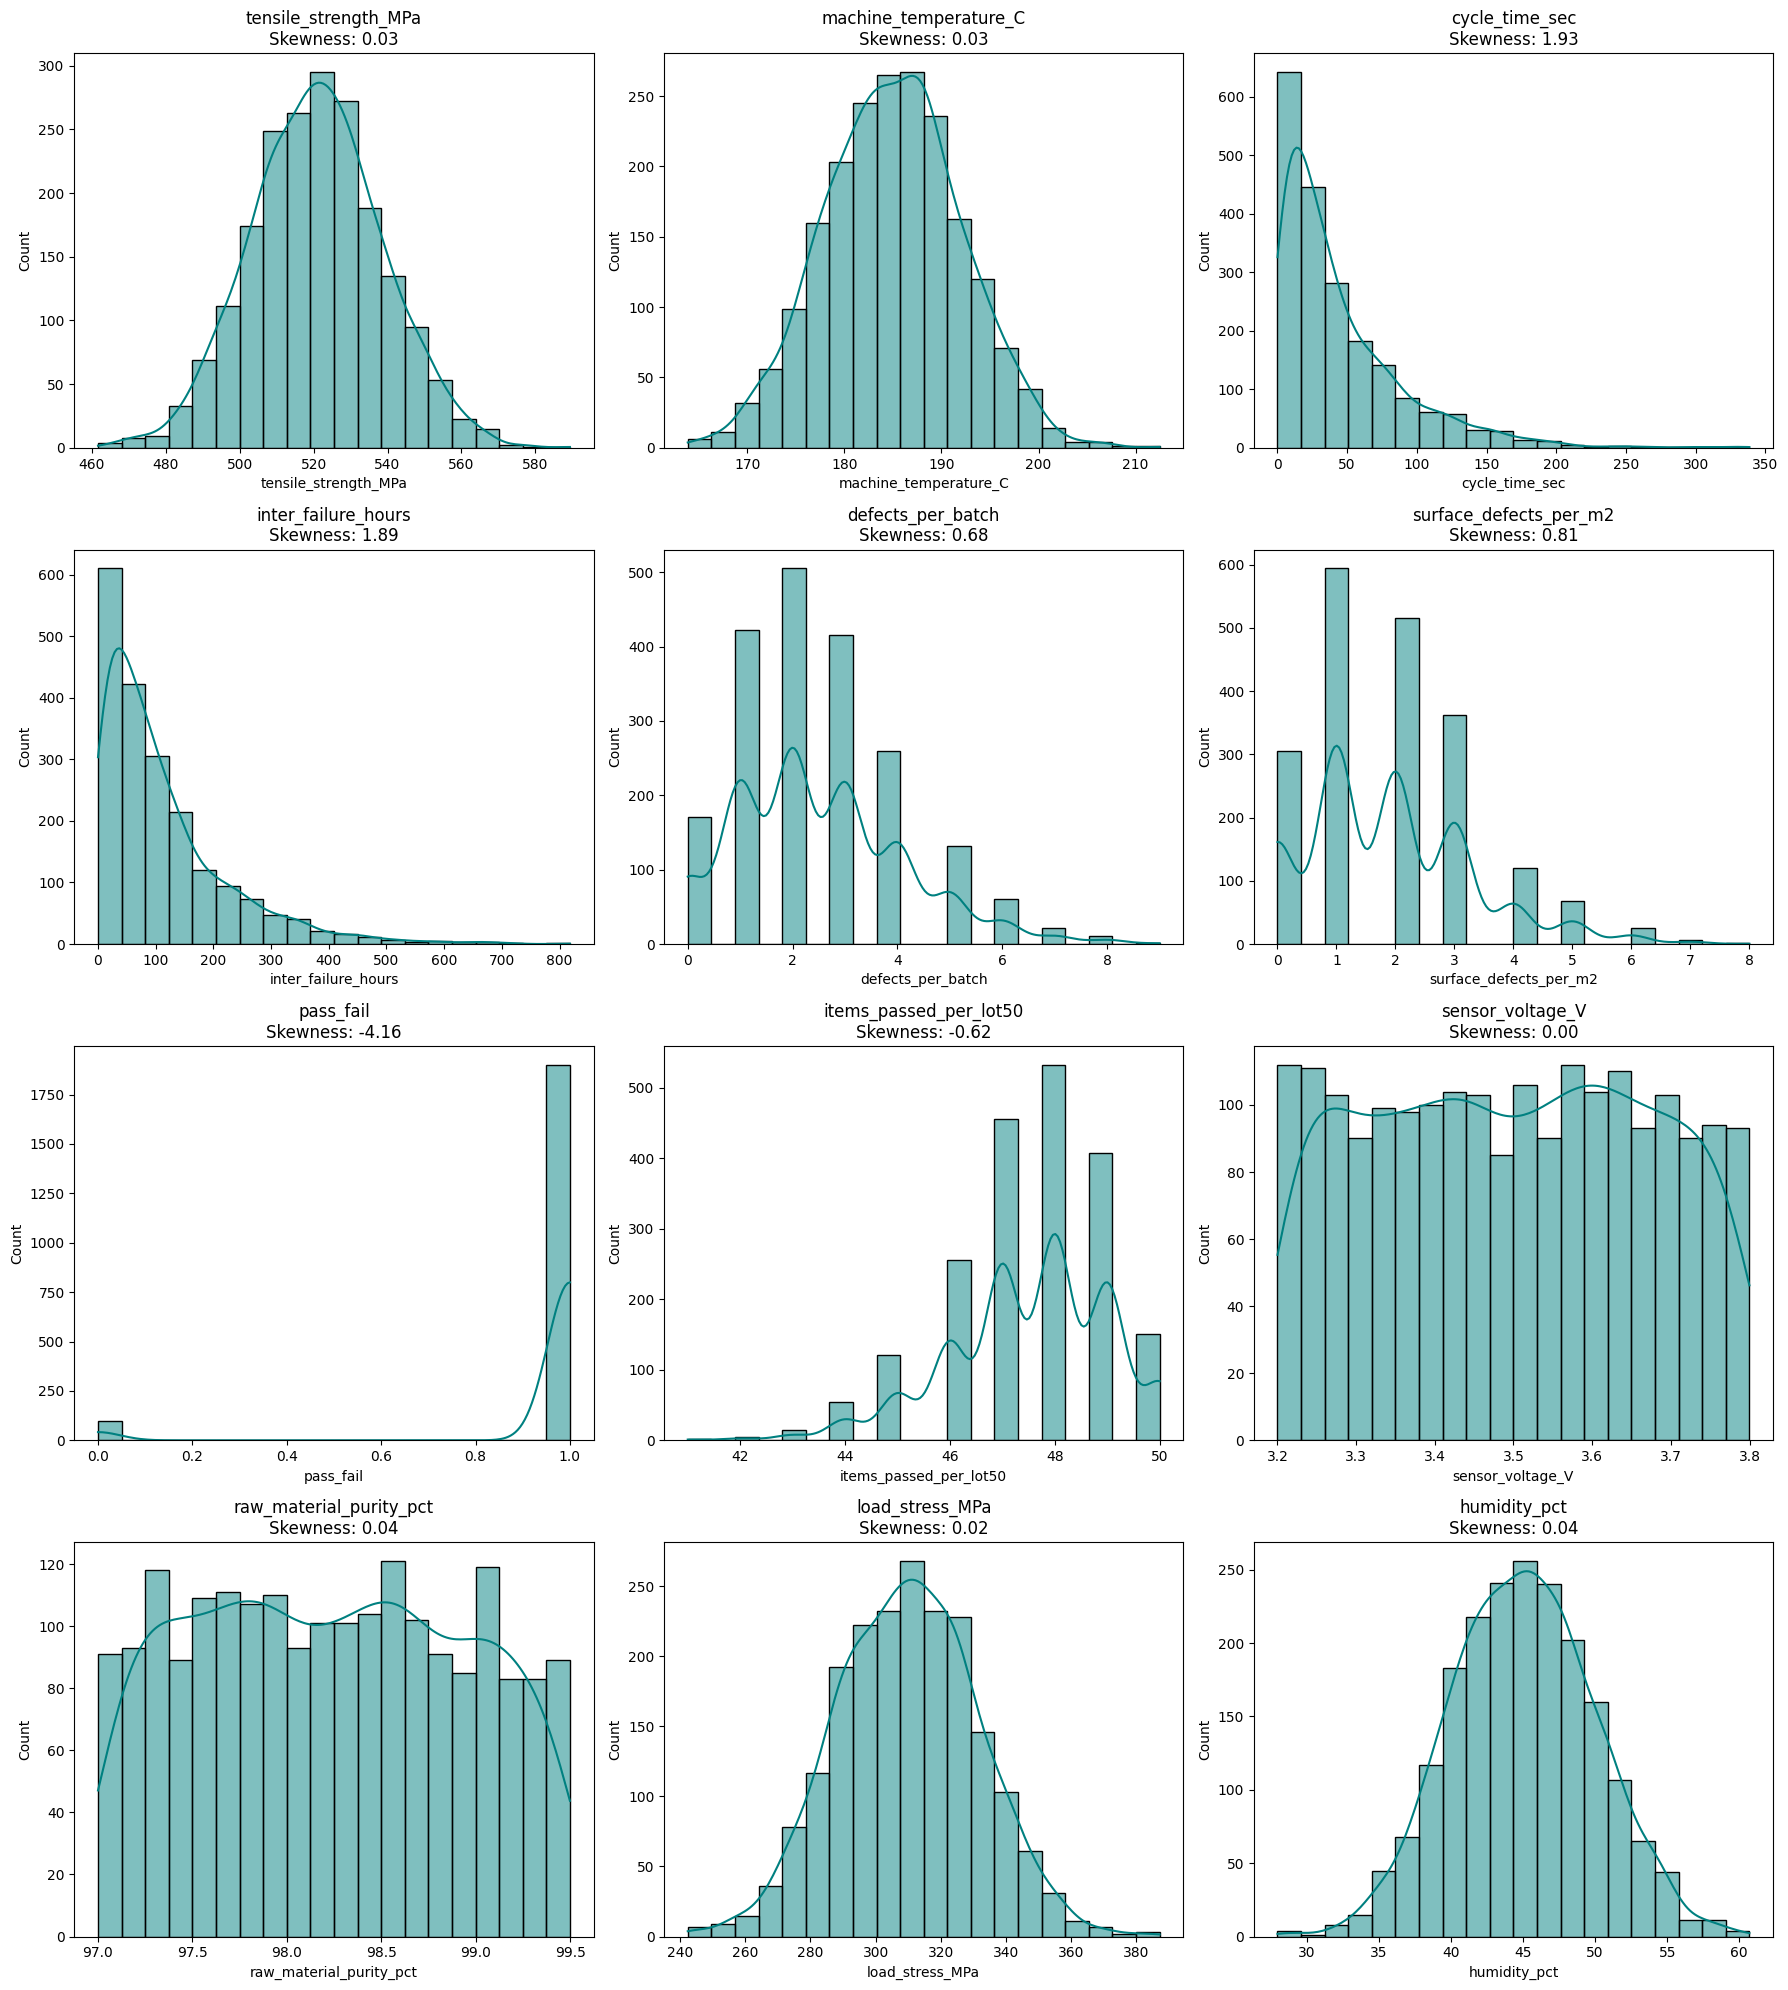

Skewness Values for Each Column:
tensile_strength_MPa: 0.03
machine_temperature_C: 0.03
cycle_time_sec: 1.93
inter_failure_hours: 1.89
defects_per_batch: 0.68
surface_defects_per_m2: 0.81
pass_fail: -4.16
items_passed_per_lot50: -0.62
sensor_voltage_V: 0.00
raw_material_purity_pct: 0.04
load_stress_MPa: 0.02
humidity_pct: 0.04


In [4]:
# 3️⃣ Check skewness for numeric columns 
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if 'batch_id' in numeric_cols:
    numeric_cols.remove('batch_id')


skewness_dict = {}
num_cols = len(numeric_cols)
cols_per_row = 3
rows = int(np.ceil(num_cols / cols_per_row))

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(numeric_cols):
    skewness = df[col].skew()
    skewness_dict[col] = skewness
    
    plt.subplot(rows, cols_per_row, i+1)
    sns.histplot(df[col], kde=True, color='teal', bins=20)
    plt.title(f"{col}\nSkewness: {skewness:.2f}")

plt.tight_layout()
plt.show()

print("Skewness Values for Each Column:")
for col, skew in skewness_dict.items():
    print(f"{col}: {skew:.2f}")


tensile_strength_MPa: p-value = 0.9084 → Normal


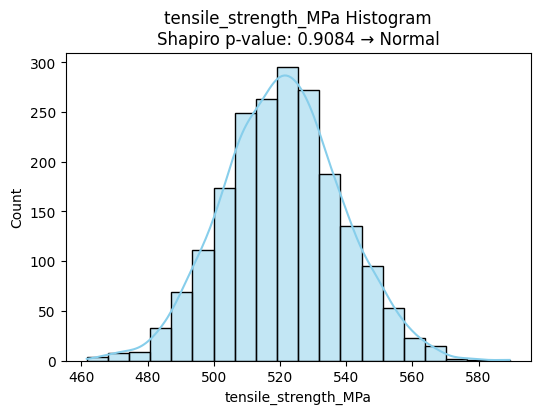

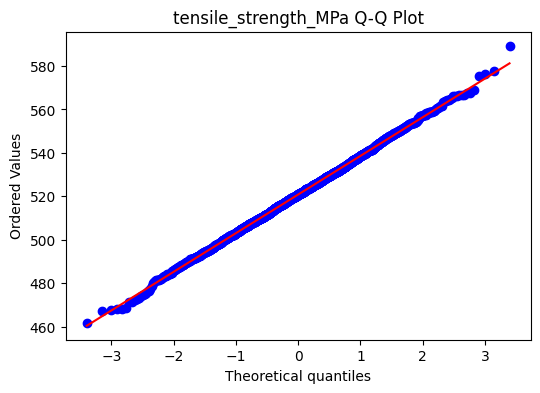

machine_temperature_C: p-value = 0.7370 → Normal


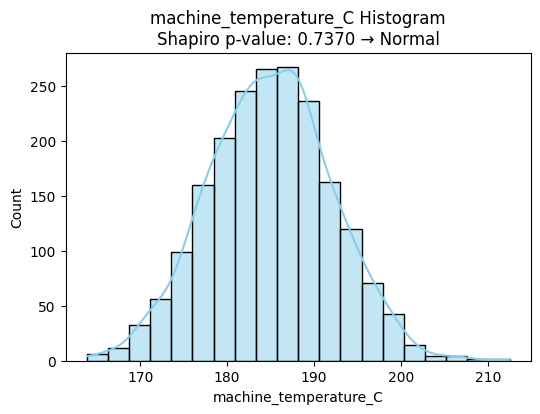

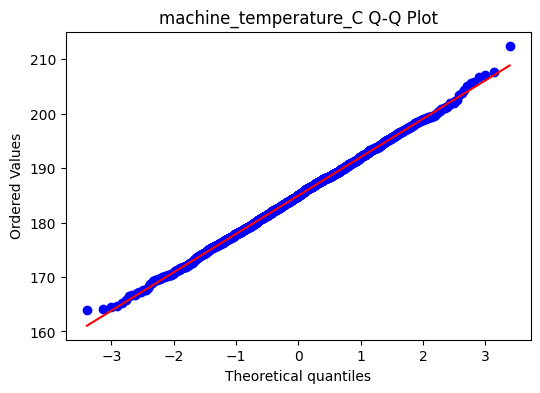

cycle_time_sec: p-value = 0.0000 → Not Normal


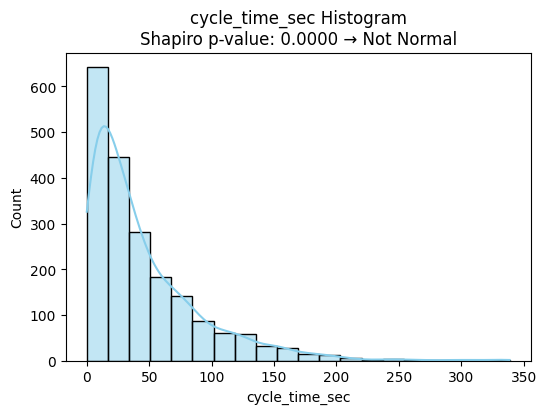

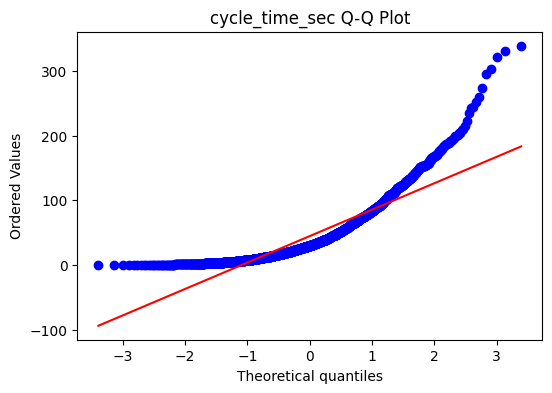

inter_failure_hours: p-value = 0.0000 → Not Normal


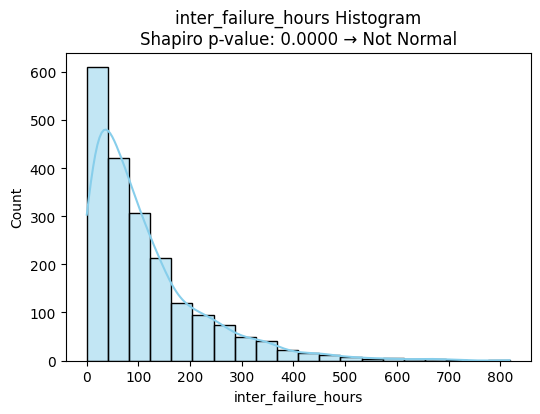

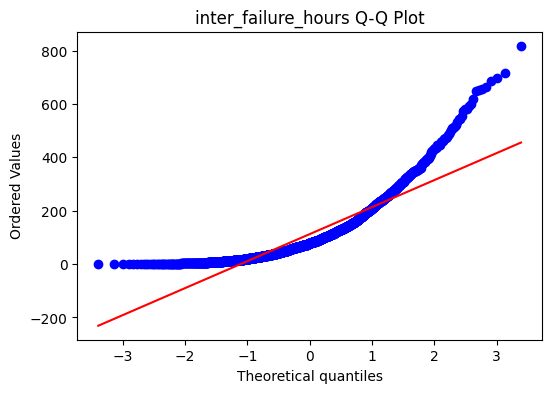

defects_per_batch: p-value = 0.0000 → Not Normal


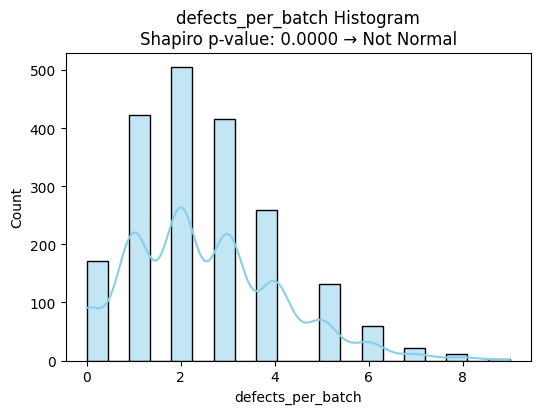

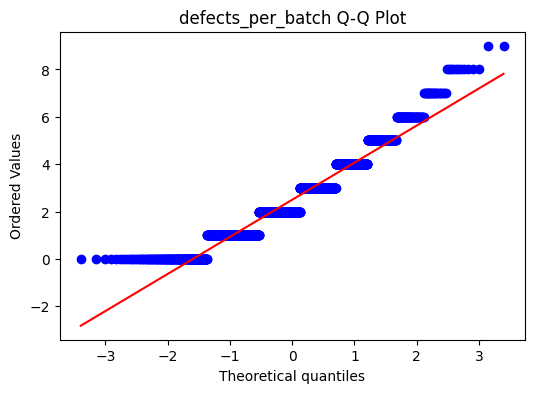

surface_defects_per_m2: p-value = 0.0000 → Not Normal


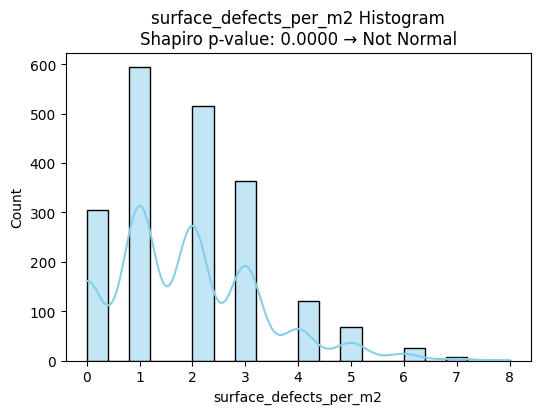

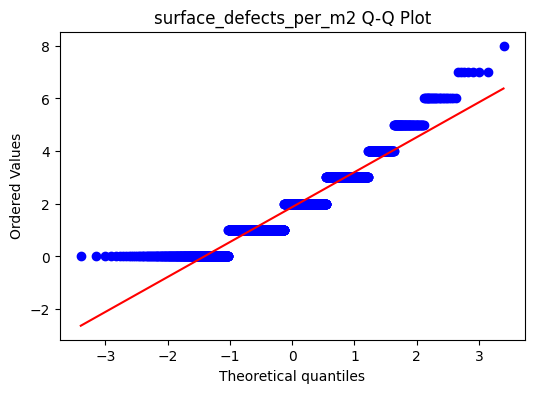

pass_fail: p-value = 0.0000 → Not Normal


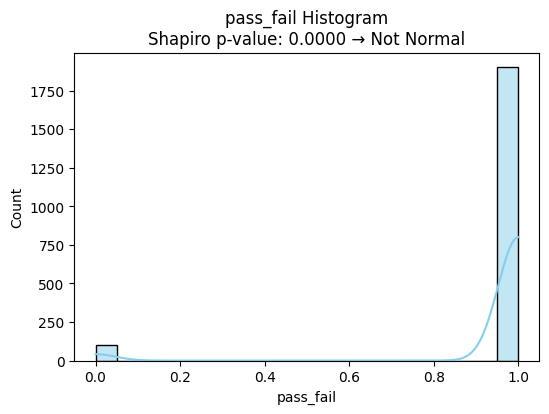

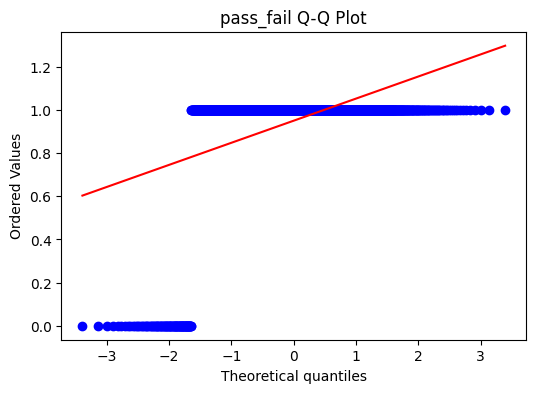

items_passed_per_lot50: p-value = 0.0000 → Not Normal


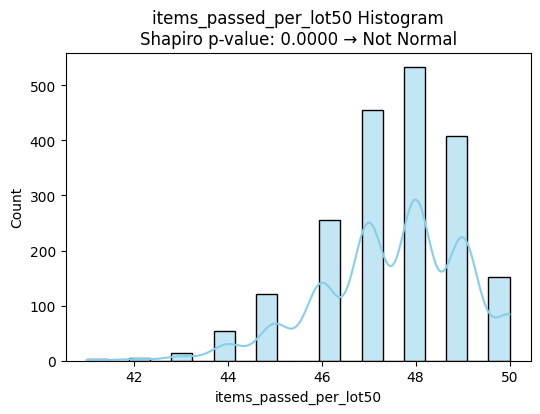

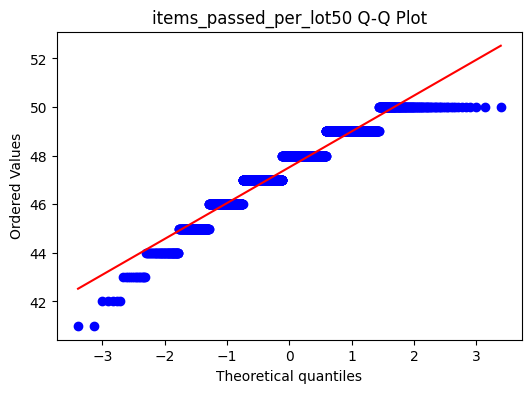

sensor_voltage_V: p-value = 0.0000 → Not Normal


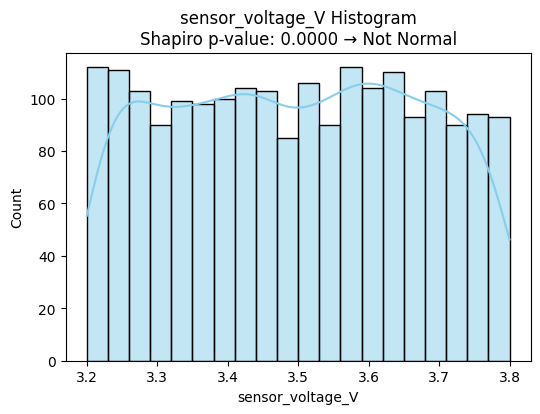

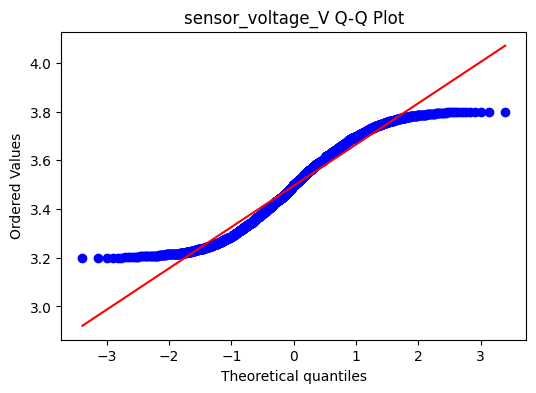

raw_material_purity_pct: p-value = 0.0000 → Not Normal


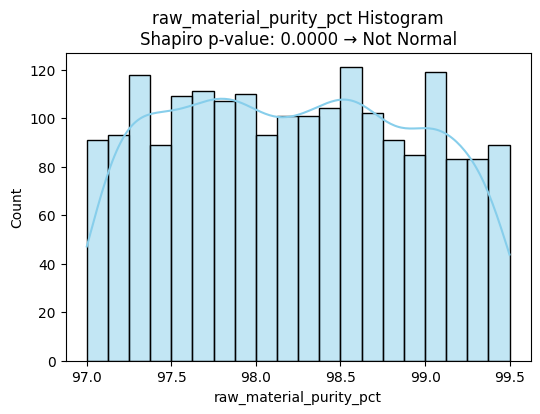

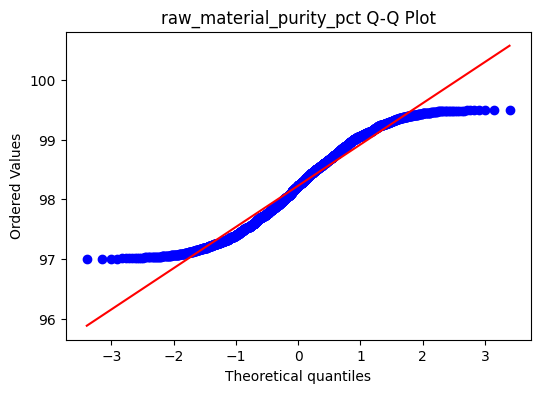

load_stress_MPa: p-value = 0.7325 → Normal


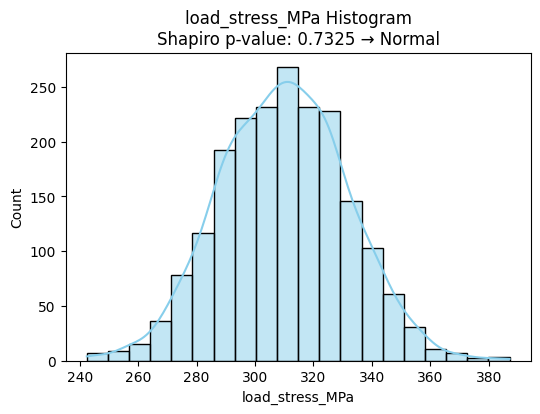

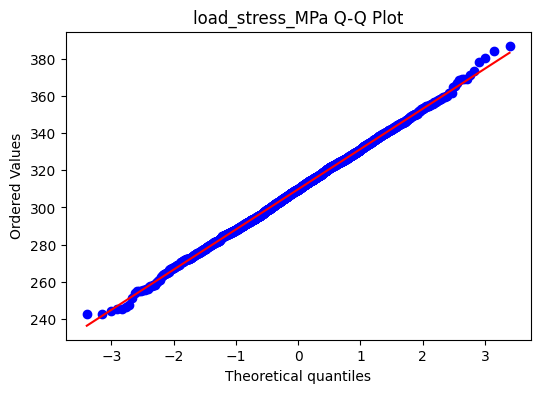

humidity_pct: p-value = 0.5728 → Normal


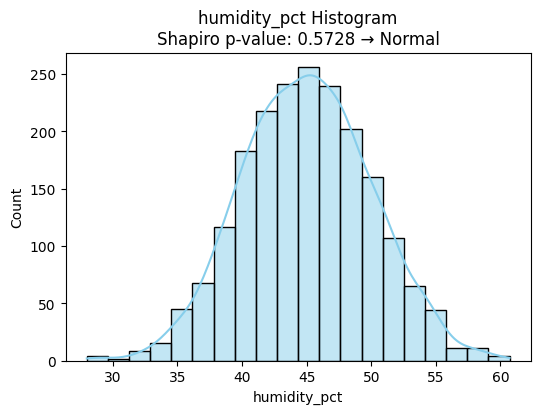

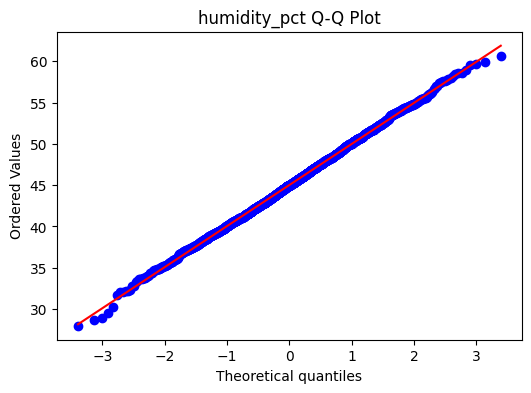

In [5]:
# 4️⃣ Normality Test (Shapiro-Wilk) - Column by Column
import scipy.stats as stats

for col in numeric_cols:
    data = df[col].dropna()
    stat, p = shapiro(data)
    result = "Normal" if p > 0.05 else "Not Normal"
    
    print(f"{col}: p-value = {p:.4f} → {result}")
    
    # Plot histogram with KDE
    plt.figure(figsize=(6,4))
    sns.histplot(data, bins=20, kde=True, color='skyblue')
    plt.title(f"{col} Histogram\nShapiro p-value: {p:.4f} → {result}")
    
    # Q-Q plot
    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"{col} Q-Q Plot")
    
    plt.show()

normality_results = {}

for col in numeric_cols:
    data = df[col].dropna()
    
    stat, p = shapiro(data)
    
    normality_results[col] = p



In [7]:
# 5️⃣ Function to Fit Distributions
def fit_distributions(col_data):
    results = {}
    data = col_data.dropna()
    n = len(data)
    
    # --- Continuous distributions (KS-test) ---
    # Normal
    mu, std = norm.fit(data)
    ks_stat, ks_p = kstest(data, 'norm', args=(mu, std))
    results['Normal'] = ks_p
    
    # Exponential (only positive)
    if (data > 0).all():
        loc_exp, scale_exp = expon.fit(data)
        ks_stat, ks_p = kstest(data, 'expon', args=(loc_exp, scale_exp))
        results['Exponential'] = ks_p
    
    # Uniform
    min_val, max_val = data.min(), data.max()
    ks_stat, ks_p = kstest(data, 'uniform', args=(min_val, max_val - min_val))
    results['Uniform'] = ks_p
    
    # Student's t
    df_t, loc_t, scale_t = t.fit(data)
    ks_stat, ks_p = kstest(data, 't', args=(df_t, loc_t, scale_t))
    results["Student's t"] = ks_p
    
    # --- Discrete distributions (Chi-square) ---
    rounded_data = np.round(data).astype(int)
    
    # Bernoulli (binary)
    if set(rounded_data).issubset({0, 1}):
        p = rounded_data.mean()
        expected = n * np.array([1-p, p])
        expected = expected / expected.sum() * n  # fix sum mismatch
        obs = [(rounded_data==0).sum(), (rounded_data==1).sum()]
        chi_stat, chi_p = chisquare(f_obs=obs, f_exp=expected)
        results['Bernoulli'] = chi_p
    
    # Binomial (discrete with limited range)
    max_val = rounded_data.max()
    if max_val > 1 and max_val <= 50:
        n_binom = max_val
        p_binom = rounded_data.mean() / n_binom
        expected = n * binom.pmf(range(0, n_binom+1), n_binom, p_binom)
        expected = expected / expected.sum() * n
        obs_counts = np.zeros(n_binom+1)
        for val, cnt in zip(*np.unique(rounded_data, return_counts=True)):
            obs_counts[val] = cnt
        chi_stat, chi_p = chisquare(f_obs=obs_counts, f_exp=expected)
        results['Binomial'] = chi_p
    
    # Poisson (counts, small range)
    if (rounded_data >= 0).all() and rounded_data.nunique() < 20:
        lambda_poisson = rounded_data.mean()
        expected = n * poisson.pmf(np.arange(0, rounded_data.max()+1), lambda_poisson)
        expected = expected / expected.sum() * n
        obs_counts = np.zeros(len(expected))
        for val, cnt in zip(*np.unique(rounded_data, return_counts=True)):
            obs_counts[val] = cnt
        chi_stat, chi_p = chisquare(f_obs=obs_counts, f_exp=expected)
        results['Poisson'] = chi_p
    
    # Select best-fit (highest p-value)
    best_dist = max(results, key=results.get)
    return best_dist, results


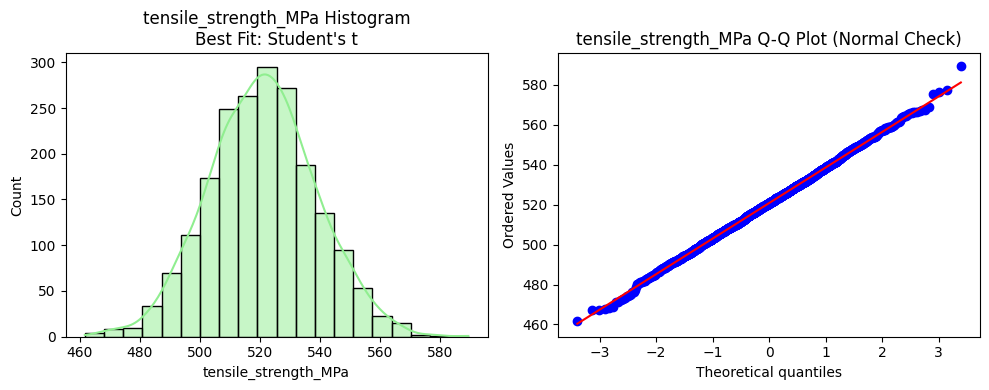

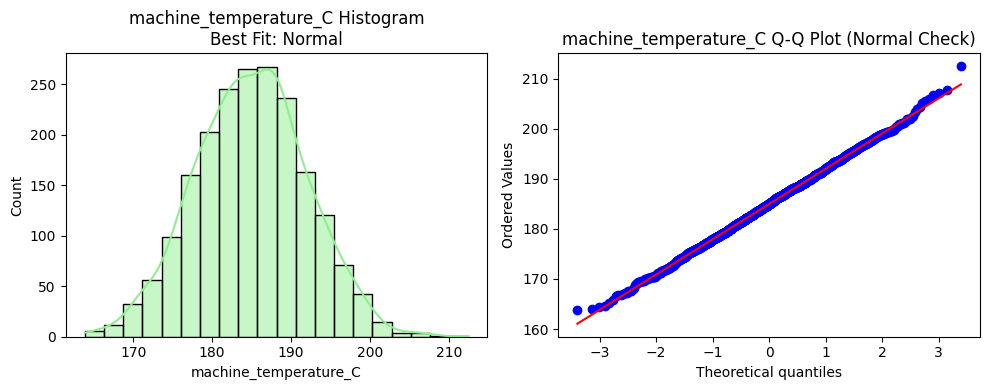

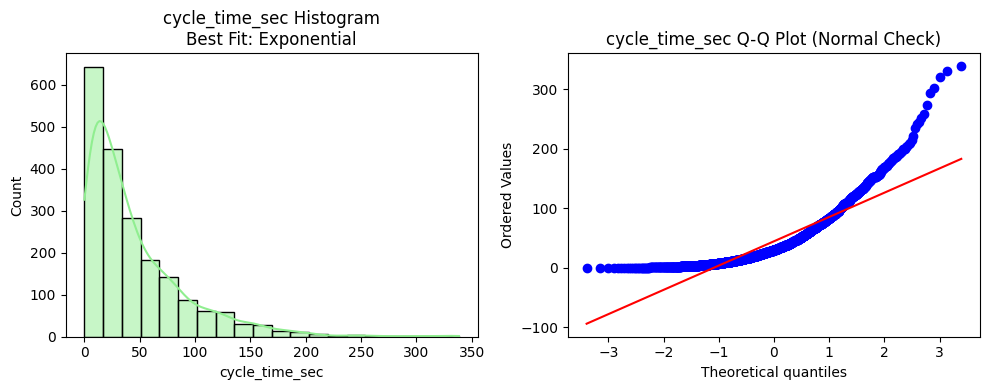

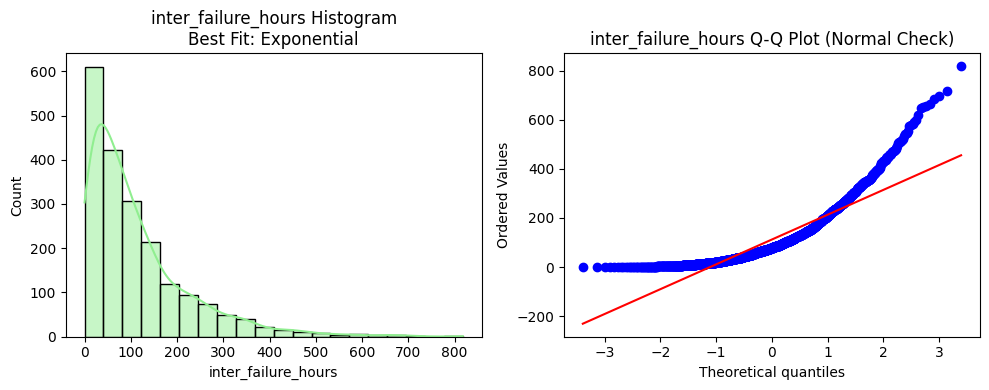

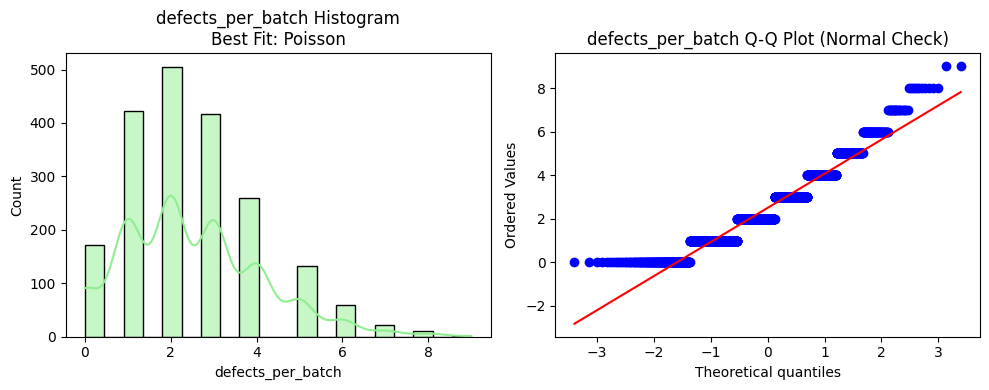

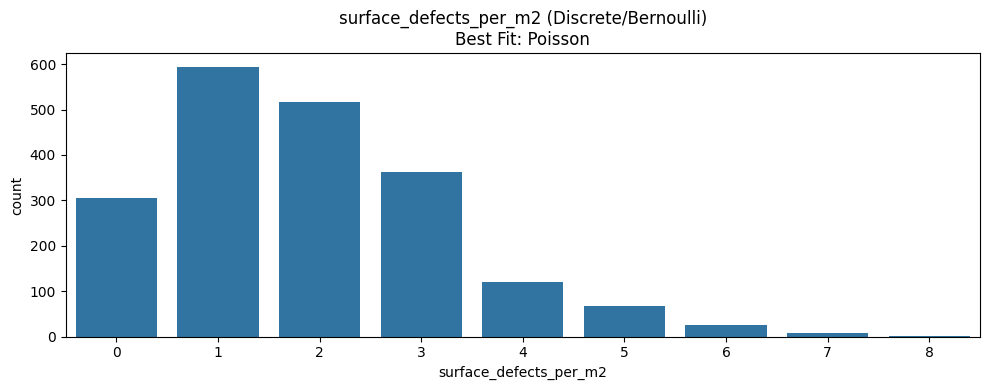

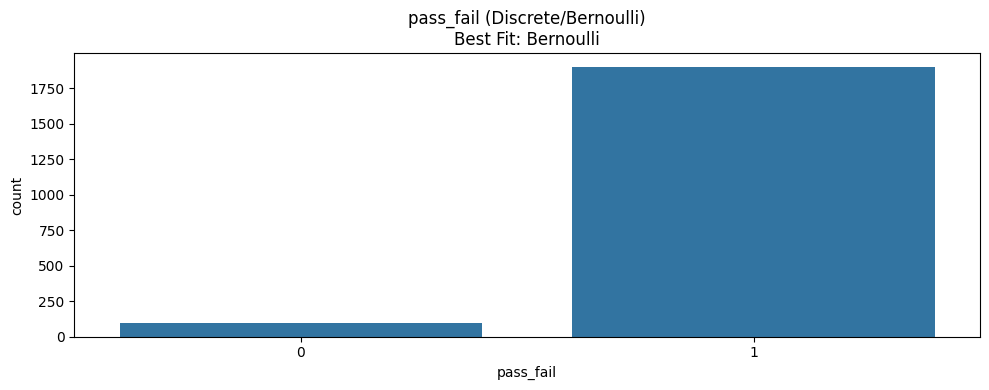

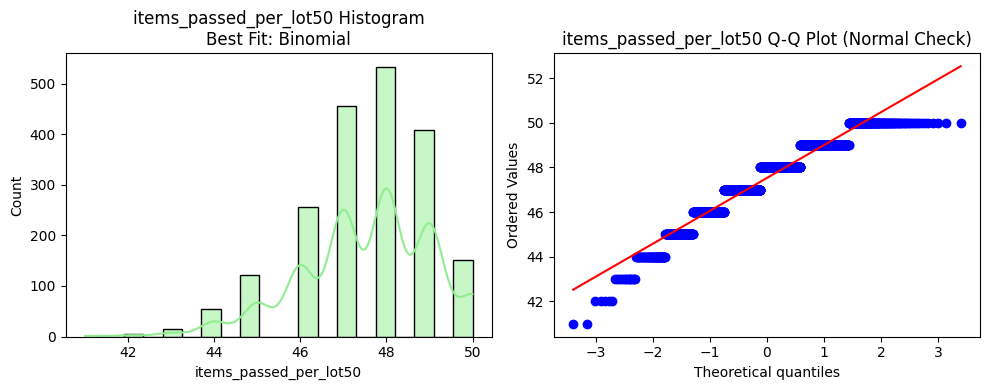

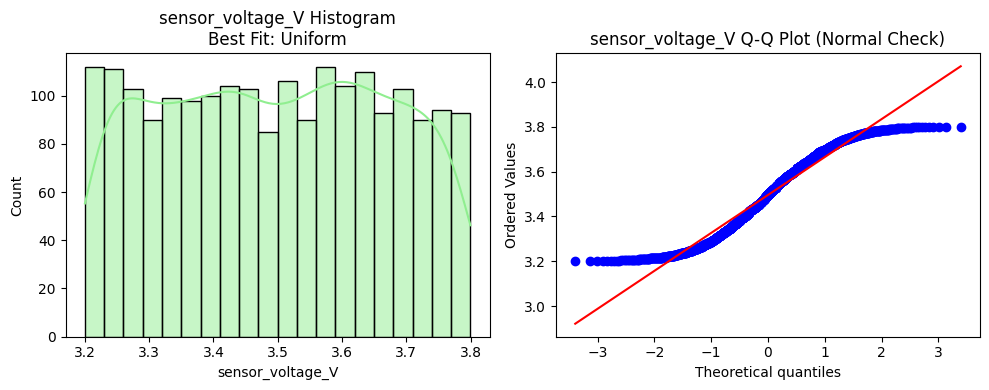

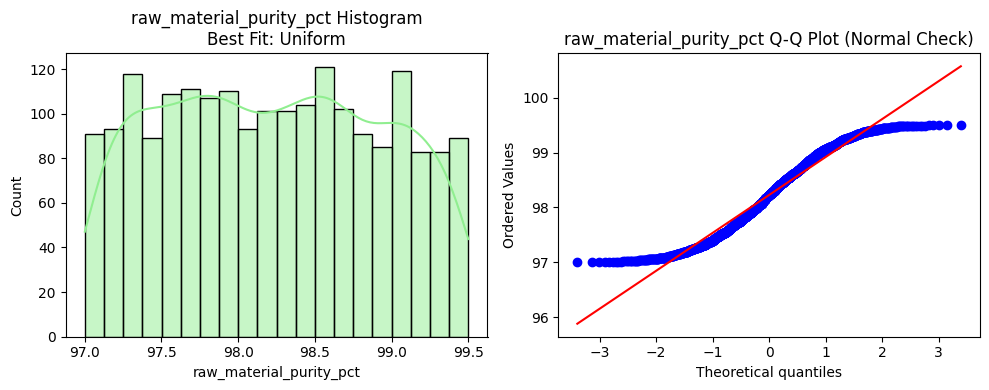

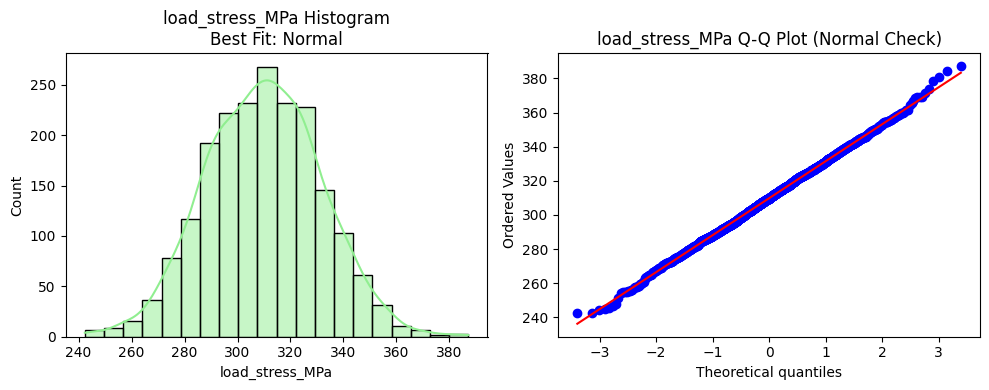

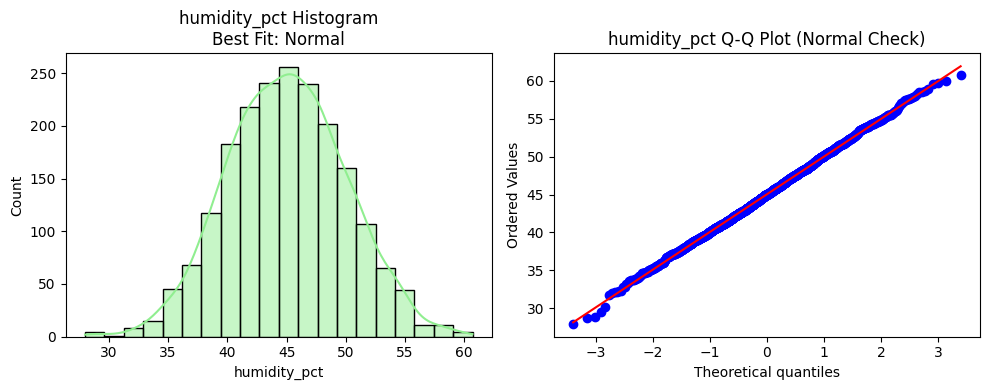

In [8]:
best_distributions = {}

for col in numeric_cols:
    data = df[col].dropna()
    best_dist, all_pvalues = fit_distributions(data)
    best_distributions[col] = best_dist

    unique_vals = data.nunique()

    plt.figure(figsize=(10, 4))

    # 🔹 Continuous Data → Show BOTH plots
    if unique_vals >= 10:
        plt.subplot(1, 2, 1)
        sns.histplot(data, bins=20, kde=True, color='lightgreen')
        plt.title(f"{col} Histogram\nBest Fit: {best_dist}")

        plt.subplot(1, 2, 2)
        stats.probplot(data, dist="norm", plot=plt)
        plt.title(f"{col} Q-Q Plot (Normal Check)")

    # 🔹 Discrete / Bernoulli → ONLY countplot
    else:
        sns.countplot(x=data)
        plt.title(f"{col} (Discrete/Bernoulli)\nBest Fit: {best_dist}")

    plt.tight_layout()
    plt.show()

In [9]:
# 7️⃣ Summary Table

summary_df = pd.DataFrame({
    "Skewness": [skewness_dict[col] for col in numeric_cols],
    "Shapiro_pvalue": [normality_results[col] for col in numeric_cols],
    "Best_Distribution": [best_distributions[col] for col in numeric_cols]
}, index=numeric_cols)

print("\n✅ Final Summary Table:")
display(summary_df)




✅ Final Summary Table:


,Skewness,Shapiro_pvalue,Best_Distribution
tensile_strength_MPa,0.032884,9.084456e-01,Student's t
machine_temperature_C,0.025854,7.369956e-01,Normal
cycle_time_sec,1.925056,4.027092e-43,Exponential
inter_failure_hours,1.888669,8.286126e-43,Exponential
defects_per_batch,0.679604,1.121367e-28,Poisson
surface_defects_per_m2,0.809472,4.698307e-33,Poisson
pass_fail,-4.156924,7.496763e-68,Bernoulli
items_passed_per_lot50,-0.615588,3.611066e-28,Binomial
sensor_voltage_V,0.000556,2.547272e-24,Uniform
raw_material_purity_pct,0.043053,3.264647e-23,Uniform
